# Customer Churn — Data Cleaning & Exploratory Data Analysis

This notebook explores the Telco Customer Churn dataset to understand which factors are associated with customer attrition. Cleaning logic lives in `src/data_cleaning.py` and is imported here rather than duplicated — the notebook is for exploration and visualization, not for holding the source of truth for data processing.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_cleaning import load_raw_data, load_clean_data

sns.set_style("whitegrid")
FIGURES_DIR = "../reports/figures"

df_raw = load_raw_data("../data/raw/Telco-Customer-Churn.csv")
df = load_clean_data("../data/raw/Telco-Customer-Churn.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


## Target Variable: Churn Distribution

Before modeling anything, we need to know how imbalanced the target is — this determines whether we need techniques like class weighting or resampling later.

Churn rate: 26.5%


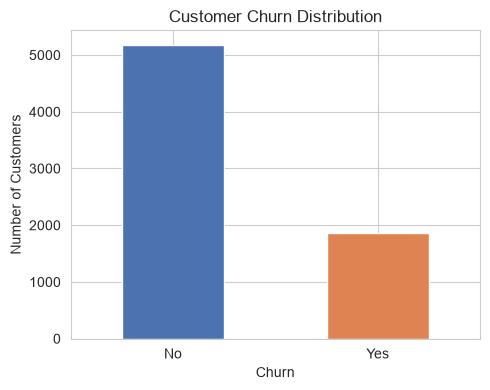

In [4]:
churn_rate = df["Churn"].mean()
print(f"Churn rate: {churn_rate:.1%}")

fig, ax = plt.subplots(figsize=(5, 4))
df["Churn"].map({0: "No", 1: "Yes"}).value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Customer Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/churn_distribution.png", dpi=150)
plt.show()

## Churn Rate by Contract Type

Contract type is a strong hypothesis for a churn driver: month-to-month customers have no penalty for leaving, unlike customers on 1- or 2-year contracts.

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


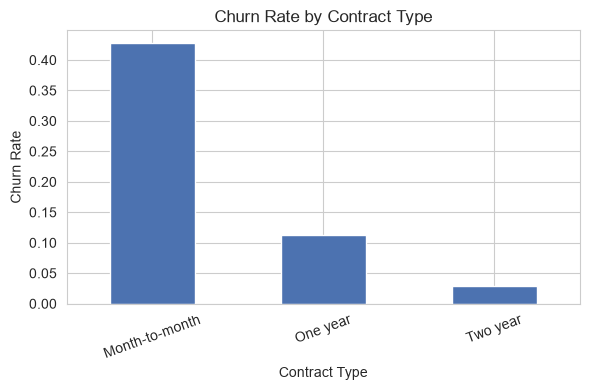

In [5]:
contract_churn = df_raw.assign(Churn=df["Churn"]).groupby("Contract")["Churn"].mean().sort_values(ascending=False)
print(contract_churn)

fig, ax = plt.subplots(figsize=(6, 4))
contract_churn.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Churn Rate by Contract Type")
ax.set_ylabel("Churn Rate")
ax.set_xlabel("Contract Type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/churn_by_contract.png", dpi=150)
plt.show()

## Tenure and Monthly Charges vs. Churn

How long a customer has stayed (tenure) and what they pay monthly are both natural candidates for churn drivers.

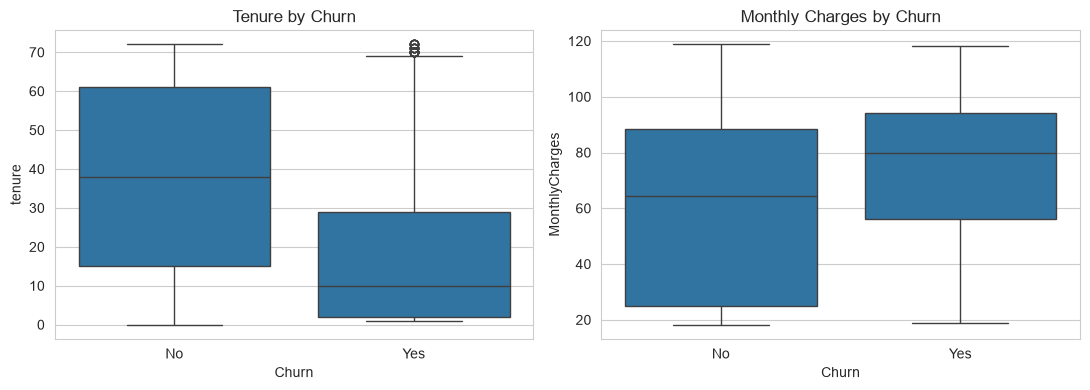

       tenure  MonthlyCharges
Churn                        
0        38.0          64.425
1        10.0          79.650


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No", "Yes"])
axes[0].set_title("Tenure by Churn")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["No", "Yes"])
axes[1].set_title("Monthly Charges by Churn")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/tenure_charges_by_churn.png", dpi=150)
plt.show()

print(df.groupby("Churn")[["tenure", "MonthlyCharges"]].median())

## Churn Rate by Internet Service and Payment Method

Service type and how customers pay are both operational levers a business could actually act on (e.g. promoting autopay, bundling security add-ons).

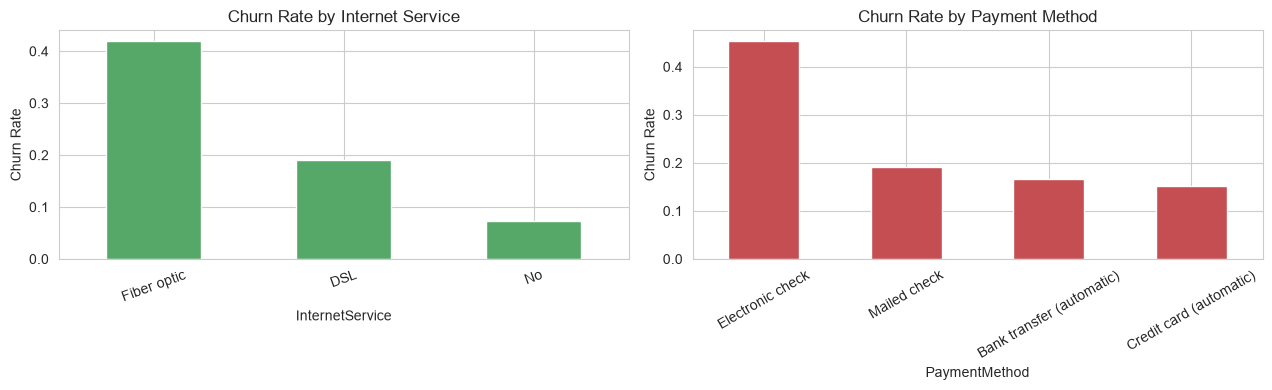

InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64

PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

internet_churn = df_raw.assign(Churn=df["Churn"]).groupby("InternetService")["Churn"].mean().sort_values(ascending=False)
internet_churn.plot(kind="bar", ax=axes[0], color="#55A868")
axes[0].set_title("Churn Rate by Internet Service")
axes[0].set_ylabel("Churn Rate")
axes[0].tick_params(axis="x", rotation=20)

payment_churn = df_raw.assign(Churn=df["Churn"]).groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False)
payment_churn.plot(kind="bar", ax=axes[1], color="#C44E52")
axes[1].set_title("Churn Rate by Payment Method")
axes[1].set_ylabel("Churn Rate")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/internet_payment_churn.png", dpi=150)
plt.show()

print(internet_churn)
print()
print(payment_churn)

## Correlation Heatmap (Numeric Features)

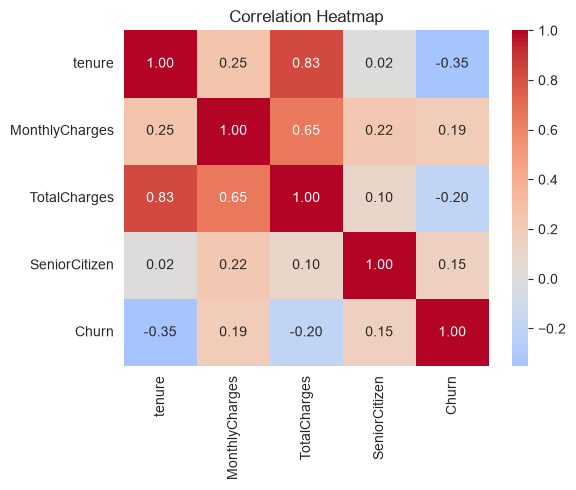

In [8]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/correlation_heatmap.png", dpi=150)
plt.show()

## Key EDA Insights

- **Overall churn rate: 26.5%** — a meaningfully imbalanced target; modeling will need to account for this (class weighting or resampling) rather than optimizing for raw accuracy alone.
- **Contract type is the strongest signal found so far**: month-to-month customers churn at 42.7%, vs. 11.3% for one-year and 2.8% for two-year contracts. Customers with no cancellation penalty leave far more often.
- **Tenure and churn are inversely related**: churned customers have a median tenure of 10 months vs. 38 months for retained customers — churn risk is concentrated early in the customer lifecycle.
- **Churned customers pay more**: median monthly charges are $79.65 for churned customers vs. $64.43 for retained ones — price sensitivity is a plausible driver, worth testing formally once feature importance is available.
- **Fiber optic internet customers churn substantially more** (41.9%) than DSL (19.0%) or no-internet customers (7.4%) — worth investigating whether this reflects service quality/pricing rather than the technology itself.
- **Payment method matters a lot**: electronic check users churn at 45.3%, more than double every other payment method (15–19%). Automatic payment methods (bank transfer, credit card) show the lowest churn — likely correlated with lower friction / more "sticky" customers rather than a causal effect of the payment method itself.

See `reports/eda_summary.md` for the business-facing writeup of these findings.